# Vergleich der vier Ergebnis-Modelle

Dieses Notebook wertet die bereits gespeicherten Testprognosen der vier erstellten Modelle aus. Es wurde anhand dieses Notebooks kein Modell erneut trainiert oder die Pipeline angepasst.

Verglichen werden:

- **ZeroR baseline** - als einfache Referenz,
- **Selected numerical model** - als primäres numerisches Modell,
- **News-only diagnostic model** - als ergänzende diagnostische Untersuchung,
- **Combined model** - als primäres Modell mit numerischen und News-Features.

Der wissenschaftliche Hauptvergleich bleibt **Selected numerical model gegen Combined model**. Alle Modelle besitzen das exakt gleiche Testset.

In [2]:
from itertools import product
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from statsmodels.stats.contingency_tables import mcnemar

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:.3f}")
plt.style.use("seaborn-v0_8-whitegrid")

CLASSES = ["H", "D", "A"]
PROBABILITY_COLUMNS = [f"probability_{label}" for label in CLASSES]


## 1. Eingabedateien

Einlesen der Daten.

In [3]:
SEASON = 2025
NEWS_FEATURES_PATH = Path(f"../data/processed/news_features_{SEASON}.csv")
MODELS = {
    "ZeroR baseline": {
        "predictions": Path(f"../outputs/modeling/{SEASON}/numerical/dummy/test_predictions.csv"),
        "report": Path(f"../outputs/modeling/{SEASON}/numerical/dummy/evaluation.json"),
    },
    "Selected numerical model": {
        "predictions": Path(f"../outputs/modeling/{SEASON}/numerical/logistic_regression/final/test_predictions.csv"),
        "report": Path(f"../outputs/modeling/{SEASON}/numerical/logistic_regression/final/evaluation.json"),
    },
    "News-only diagnostic model": {
        "predictions": Path(f"../outputs/modeling/{SEASON}/news/logistic_regression/diagnostic/test_predictions.csv"),
        "report": Path(f"../outputs/modeling/{SEASON}/news/logistic_regression/diagnostic/evaluation.json"),
    },
    "Combined model": {
        "predictions": Path(f"../outputs/modeling/{SEASON}/combined/logistic_regression/final/test_predictions.csv"),
        "report": Path(f"../outputs/modeling/{SEASON}/combined/logistic_regression/final/evaluation.json"),
    },
}

input_rows = []
for model_name, paths in MODELS.items():
    for artifact_name, path in paths.items():
        if not path.is_file():
            raise FileNotFoundError(f"{model_name}: {artifact_name} fehlt: {path}")
        input_rows.append({
            "Bereich": model_name,
            "Artefakt": artifact_name,
            "Pfad": path.as_posix(),
        })
if not NEWS_FEATURES_PATH.is_file():
    raise FileNotFoundError(f"News-Features fehlen: {NEWS_FEATURES_PATH}")
input_rows.append({
    "Bereich": "Spielbezogene Einordnung",
    "Artefakt": "aggregated_news_features",
    "Pfad": NEWS_FEATURES_PATH.as_posix(),
})

print(f"Saison: {SEASON}/{str(SEASON + 1)[-2:]}")
display(pd.DataFrame(input_rows))


Saison: 2025/26


,Bereich,Artefakt,Pfad
0,ZeroR baseline,predictions,../outputs/modeling/2025/numerical/dummy/test_...
1,ZeroR baseline,report,../outputs/modeling/2025/numerical/dummy/evalu...
2,Selected numerical model,predictions,../outputs/modeling/2025/numerical/logistic_re...
3,Selected numerical model,report,../outputs/modeling/2025/numerical/logistic_re...
4,News-only diagnostic model,predictions,../outputs/modeling/2025/news/logistic_regress...
5,News-only diagnostic model,report,../outputs/modeling/2025/news/logistic_regress...
6,Combined model,predictions,../outputs/modeling/2025/combined/logistic_reg...
7,Combined model,report,../outputs/modeling/2025/combined/logistic_reg...
8,Spielbezogene Einordnung,aggregated_news_features,../data/processed/news_features_2025.csv


## 2. Laden und Validieren

Vor der Analyse wird geprüft, dass alle Modelle genau dieselben Spiele, tatsächlichen Ergebnisse und Metadaten verwenden und dass ihre Wahrscheinlichkeiten gültig sind.

In [4]:
REQUIRED_COLUMNS = {
    "match_id",
    "season",
    "league",
    "matchday",
    "kickoff",
    "home_team_id",
    "home_team",
    "away_team_id",
    "away_team",
    "dataset_split",
    "actual_result",
    "predicted_result",
    *PROBABILITY_COLUMNS,
}
METADATA_COLUMNS = [
    "match_id",
    "season",
    "league",
    "matchday",
    "kickoff",
    "home_team_id",
    "home_team",
    "away_team_id",
    "away_team",
    "dataset_split",
    "actual_result",
]


def load_predictions(path: Path) -> pd.DataFrame:
    frame = pd.read_csv(path, encoding="utf-8")
    missing_columns = REQUIRED_COLUMNS.difference(frame.columns)
    if missing_columns:
        raise ValueError(f"Fehlende Spalten in {path}: {sorted(missing_columns)}")
    if frame["match_id"].duplicated().any():
        raise ValueError(f"Doppelte match_id in {path}")
    if set(frame["dataset_split"]) != {"test"}:
        raise ValueError(f"Nicht ausschließlich Testzeilen in {path}")
    if not set(frame["actual_result"]).issubset(CLASSES):
        raise ValueError(f"Ungültige Zielklasse in {path}")
    probabilities = frame[PROBABILITY_COLUMNS].to_numpy(dtype=float)
    if not np.isfinite(probabilities).all():
        raise ValueError(f"Nicht-endliche Wahrscheinlichkeit in {path}")
    if ((probabilities < 0.0) | (probabilities > 1.0)).any():
        raise ValueError(f"Wahrscheinlichkeit außerhalb [0, 1] in {path}")
    if not np.allclose(probabilities.sum(axis=1), 1.0, atol=1e-10):
        raise ValueError(f"Wahrscheinlichkeiten summieren sich nicht zu 1 in {path}")
    expected_prediction = np.asarray(CLASSES)[probabilities.argmax(axis=1)]
    if not np.array_equal(expected_prediction, frame["predicted_result"].to_numpy()):
        raise ValueError(f"predicted_result stimmt nicht mit argmax überein: {path}")
    frame["kickoff"] = pd.to_datetime(frame["kickoff"], utc=True)
    return frame.sort_values(["kickoff", "match_id"]).reset_index(drop=True)


predictions = {name: load_predictions(paths["predictions"]) for name, paths in MODELS.items()}
reference_metadata = predictions["Selected numerical model"][METADATA_COLUMNS]
for model_name, frame in predictions.items():
    pd.testing.assert_frame_equal(
        reference_metadata,
        frame[METADATA_COLUMNS],
        check_dtype=False,
        obj=f"Metadatenvergleich Selected numerical model vs. {model_name}",
    )

print(f"Validiert: {len(reference_metadata)} identische Testspiele in {len(predictions)} Modellen.")
display(reference_metadata.head())


Validiert: 63 identische Testspiele in 4 Modellen.


,match_id,season,league,matchday,kickoff,home_team_id,home_team,away_team_id,away_team,dataset_split,actual_result
0,77500,2025,bl1,28,2026-04-04 13:30:00+00:00,6,Bayer 04 Leverkusen,131,VfL Wolfsburg,test,H
1,77502,2025,bl1,28,2026-04-04 13:30:00+00:00,112,SC Freiburg,40,FC Bayern München,test,A
2,77503,2025,bl1,28,2026-04-04 13:30:00+00:00,134,SV Werder Bremen,1635,RB Leipzig,test,A
3,77505,2025,bl1,28,2026-04-04 13:30:00+00:00,87,Borussia Mönchengladbach,199,1. FC Heidenheim 1846,test,D
4,77507,2025,bl1,28,2026-04-04 13:30:00+00:00,175,TSG Hoffenheim,81,1. FSV Mainz 05,test,A


## 3. Metriken pro Spiel und globale Ergebnisse

In [5]:
CLASS_INDEX = {label: index for index, label in enumerate(CLASSES)}


def add_row_metrics(frame: pd.DataFrame) -> pd.DataFrame:
    enriched = frame.copy()
    probabilities = enriched[PROBABILITY_COLUMNS].to_numpy(dtype=float)
    actual_indices = enriched["actual_result"].map(CLASS_INDEX).to_numpy(dtype=int)
    actual_probabilities = probabilities[np.arange(len(enriched)), actual_indices]
    one_hot = np.eye(len(CLASSES), dtype=float)[actual_indices]
    enriched["row_log_loss"] = -np.log(np.clip(actual_probabilities, 1e-15, 1.0))
    enriched["row_brier"] = np.square(one_hot - probabilities).sum(axis=1)
    enriched["correct"] = enriched["predicted_result"].eq(enriched["actual_result"])
    return enriched


def summarize_model(frame: pd.DataFrame) -> dict[str, float]:
    return {
        "Log Loss": frame["row_log_loss"].mean(),
        "Brier Score": frame["row_brier"].mean(),
        "Accuracy": accuracy_score(frame["actual_result"], frame["predicted_result"]),
        "Macro-F1": f1_score(
            frame["actual_result"],
            frame["predicted_result"],
            labels=CLASSES,
            average="macro",
            zero_division=0,
        ),
    }


predictions = {name: add_row_metrics(frame) for name, frame in predictions.items()}
global_metrics = pd.DataFrame({name: summarize_model(frame) for name, frame in predictions.items()}).T

REPORT_METRIC_NAMES = {
    "Log Loss": "log_loss",
    "Brier Score": "multiclass_brier_score",
    "Accuracy": "accuracy",
    "Macro-F1": "macro_f1",
}
for model_name, paths in MODELS.items():
    report = json.loads(paths["report"].read_text(encoding="utf-8"))
    for display_name, report_name in REPORT_METRIC_NAMES.items():
        if not np.isclose(global_metrics.loc[model_name, display_name], report["metrics"][report_name], atol=1e-12):
            raise ValueError(f"Neu berechnete Metrik weicht vom Report ab: {model_name}, {display_name}")

display(global_metrics)
print("Alle neu berechneten Metriken stimmen mit den gespeicherten evaluation.json-Reports überein.")


,Log Loss,Brier Score,Accuracy,Macro-F1
ZeroR baseline,1.096,0.666,0.381,0.184
Selected numerical model,1.061,0.636,0.492,0.367
News-only diagnostic model,1.080,0.660,0.397,0.250
Combined model,1.053,0.630,0.476,0.360


Alle neu berechneten Metriken stimmen mit den gespeicherten evaluation.json-Reports überein.


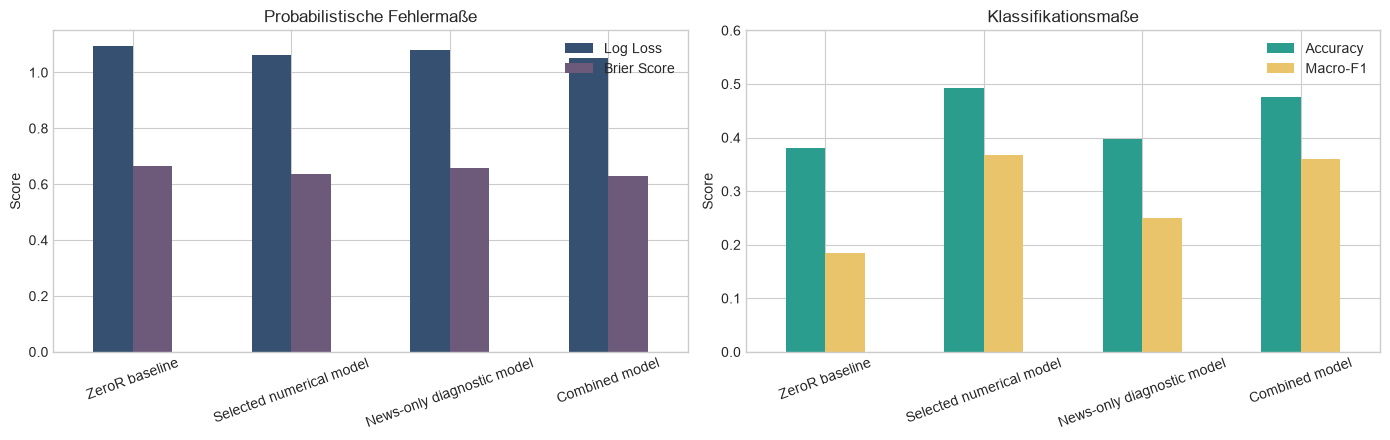

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
global_metrics[["Log Loss", "Brier Score"]].plot.bar(ax=axes[0], rot=20, color=["#355070", "#6d597a"])
axes[0].set_title("Probabilistische Fehlermaße")
axes[0].set_ylabel("Score")
global_metrics[["Accuracy", "Macro-F1"]].plot.bar(ax=axes[1], rot=20, color=["#2a9d8f", "#e9c46a"])
axes[1].set_title("Klassifikationsmaße")
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 0.6)
fig.tight_layout()
plt.show()


## 4. Klassenweise Ergebnisse und Konfusionsmatrizen

Globale Metriken können verdecken, dass ein Modell eine Ergebnisklasse kaum erkennt. Deshalb werden H, D und A getrennt untersucht.

**Anmerkung zur Tabelle:** Wird eine Ergebnisklasse von einem Modell keinmal vorhergesagt, ist die Precision für diese Klasse nicht definiert. In der Tabelle wird sie als 0,000 ausgewiesen.


In [7]:
class_rows = []
for model_name, frame in predictions.items():
    precision, recall, f1, support = precision_recall_fscore_support(
        frame["actual_result"],
        frame["predicted_result"],
        labels=CLASSES,
        zero_division=0,
    )
    for index, result_class in enumerate(CLASSES):
        class_subset = frame.loc[frame["actual_result"].eq(result_class)]
        class_rows.append({
            "model": model_name,
            "class": result_class,
            "support": int(support[index]),
            "predicted_count": int(frame["predicted_result"].eq(result_class).sum()),
            "precision": precision[index],
            "recall": recall[index],
            "f1": f1[index],
            "mean_log_loss_for_actual_class": class_subset["row_log_loss"].mean(),
            "mean_brier_for_actual_class": class_subset["row_brier"].mean(),
        })

class_metrics = pd.DataFrame(class_rows).set_index(["model", "class"])
display(class_metrics)


support  predicted_count  precision  recall  \
model                      class                                                
ZeroR baseline             H           24               63      0.381   1.000   
                           D           16                0      0.000   0.000   
                           A           23                0      0.000   0.000   
Selected numerical model   H           24               46      0.457   0.875   
                           D           16                0      0.000   0.000   
                           A           23               17      0.588   0.435   
News-only diagnostic model H           24               56      0.393   0.917   
                           D           16                0      0.000   0.000   
                           A           23                7      0.429   0.130   
Combined model             H           24               43      0.442   0.792   
                           D           16                0      0.000   0.000   
                           A           23               20      0.550   0.478   

                                    f1  mean_log_loss_for_actual_class  \
model                      class                                         
ZeroR baseline             H     0.552                           0.793   
                           D     0.000                           1.416   
                           A     0.000                           1.189   
Selected numerical model   H     0.600                           0.693   
                           D     0.000                           1.514   
                           A     0.500                           1.130   
News-only diagnostic model H     0.550                           0.752   
                           D     0.000                           1.419   
                           A     0.200                           1.186   
Combined model             H     0.567                           0.677   
                           D     0.000                           1.500   
                           A     0.512                           1.135   

                                  mean_brier_for_actual_class  
model                      class                               
ZeroR baseline             H                            0.451  
                           D                            0.871  
                           A                            0.748  
Selected numerical model   H                            0.379  
                           D                            0.949  
                           A                            0.688  
News-only diagnostic model H                            0.425  
                           D                            0.884  
                           A                            0.749  
Combined model             H                            0.368  
                           D                            0.939  
                           A                            0.688

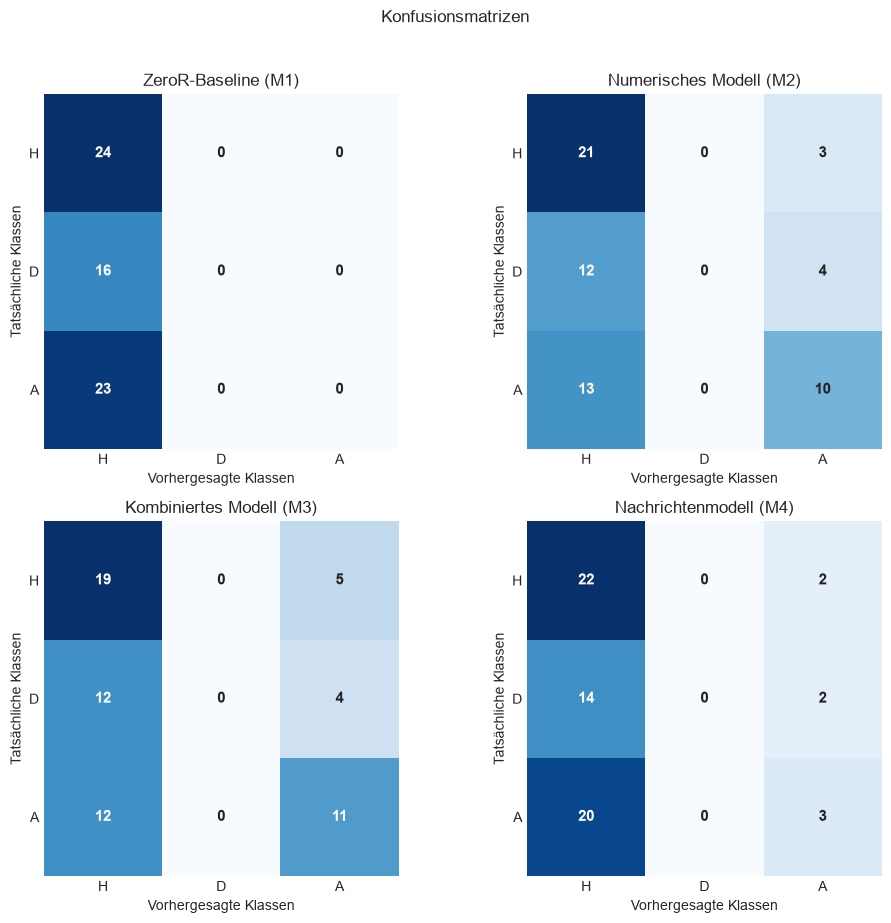

In [8]:
confusion_model_labels = {
    "ZeroR baseline": "ZeroR-Baseline (M1)",
    "Selected numerical model": "Numerisches Modell (M2)",
    "Combined model": "Kombiniertes Modell (M3)",
    "News-only diagnostic model": "Nachrichtenmodell (M4)",
}

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for axis, (model_name, model_label) in zip(axes.flat, confusion_model_labels.items(), strict=True):
    frame = predictions[model_name]
    matrix = confusion_matrix(frame["actual_result"], frame["predicted_result"], labels=CLASSES)
    axis.imshow(
        matrix,
        cmap="Blues",
        vmin=0,
        vmax=max(1, matrix.max()),
        interpolation="nearest",
    )
    contrast_threshold = matrix.max() / 2
    for row_index in range(len(CLASSES)):
        for column_index in range(len(CLASSES)):
            value = matrix[row_index, column_index]
            text_color = "white" if value > contrast_threshold else "#222222"
            axis.text(
                column_index,
                row_index,
                value,
                ha="center",
                va="center",
                color=text_color,
                fontsize=11,
                fontweight="bold",
            )
    axis.set_xticks(range(len(CLASSES)), CLASSES)
    axis.set_yticks(range(len(CLASSES)), CLASSES)
    axis.set_xlabel("Vorhergesagte Klassen")
    axis.set_ylabel("Tatsächliche Klassen")
    axis.set_title(model_label)
    axis.grid(False)
    axis.tick_params(axis="both", which="both", length=0)
    for spine in axis.spines.values():
        spine.set_visible(False)
fig.suptitle("Konfusionsmatrizen", y=1.02)
fig.tight_layout()
plt.show()


### Beobachtete Klassenanteile und mittlere Modellwahrscheinlichkeiten

Der Plot vergleicht die tatsächliche Ergebnisverteilung im Testset mit den im Mittel vergebenen Klassenwahrscheinlichkeiten der Modelle.

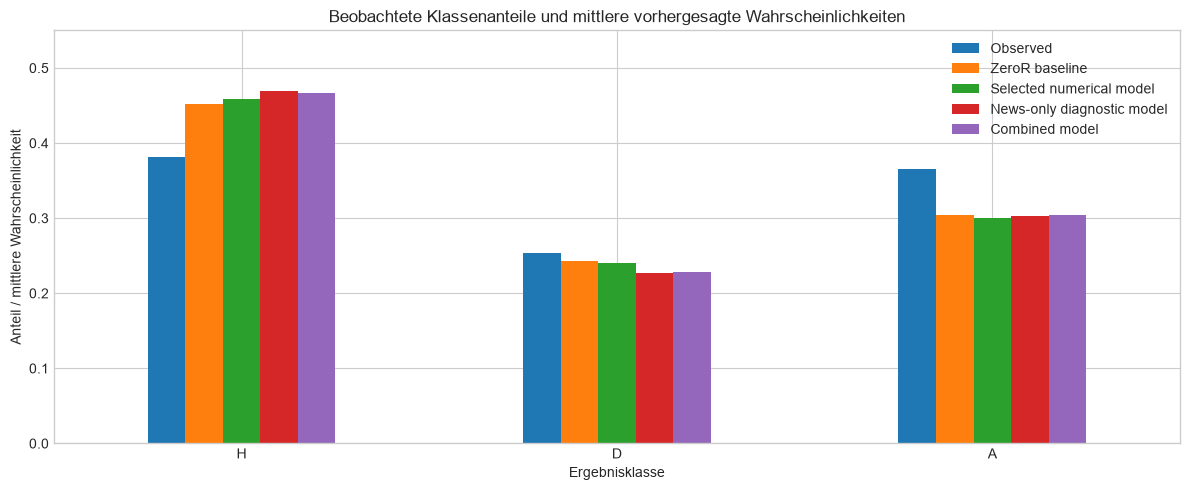

In [9]:
observed_shares = reference_metadata["actual_result"].value_counts(normalize=True).reindex(CLASSES)
probability_balance = pd.DataFrame({
    "Observed": observed_shares,
    **{
        model_name: pd.Series(
            frame[PROBABILITY_COLUMNS].mean().to_numpy(),
            index=CLASSES,
        )
        for model_name, frame in predictions.items()
    },
})
probability_balance.plot.bar(figsize=(12, 5), rot=0)
plt.title("Beobachtete Klassenanteile und mittlere vorhergesagte Wahrscheinlichkeiten")
plt.xlabel("Ergebnisklasse")
plt.ylabel("Anteil / mittlere Wahrscheinlichkeit")
plt.ylim(0, 0.55)
plt.tight_layout()
plt.show()


## 5. Gepaarte Vergleiche mit `Selected numerical model`

Untersucht werden zwei vorab festgelegte Modellvergleiche: `Selected numerical model` gegenüber der `ZeroR baseline` und `Combined model` gegenüber `Selected numerical model`. Ein positiver Gewinn bedeutet eine bessere Leistung des jeweils zuerst genannten Modells.

### Log Loss: exakter Fisher-Permutationstest auf Spieltagsebene

Der zweiseitige Test verwendet die sieben mittleren Matchday-Differenzen aus dem Testset. Wegen nur 128 möglicher Vorzeichenkombinationen sind die p-Werte vorsichtig zu interpretieren.

In [10]:
def exact_matchday_fisher_p_value(matchday_gains: np.ndarray) -> float:
    observed = abs(matchday_gains.mean())
    null_statistics = [
        abs(np.mean(matchday_gains * np.asarray(signs)))
        for signs in product((-1.0, 1.0), repeat=len(matchday_gains))
    ]
    return float(np.mean(np.asarray(null_statistics) >= observed - 1e-15))


def log_loss_significance_comparison(
    baseline: pd.DataFrame,
    candidate: pd.DataFrame,
) -> dict[str, float | bool]:
    matchday_gains = (
        baseline.assign(gain=baseline["row_log_loss"] - candidate["row_log_loss"])
        .groupby("matchday")["gain"]
        .mean()
        .to_numpy()
    )
    p_value = exact_matchday_fisher_p_value(matchday_gains)
    return {
        "mean_log_loss_gain": matchday_gains.mean(),
        "fisher_p_value": p_value,
        "significant_at_0_05": p_value < 0.05,
    }


MODEL_COMPARISONS = {
    "Selected numerical model vs. ZeroR baseline": ("ZeroR baseline", "Selected numerical model"),
    "Combined model vs. Selected numerical model": ("Selected numerical model", "Combined model"),
}
log_loss_significance_results = pd.DataFrame({
    comparison_name: log_loss_significance_comparison(
        predictions[baseline_name],
        predictions[candidate_name],
    )
    for comparison_name, (baseline_name, candidate_name) in MODEL_COMPARISONS.items()
}).T
comparison_model_labels = {
    "ZeroR baseline": "ZeroR-Baseline (M1)",
    "Selected numerical model": "Numerisches Modell (M2)",
    "Combined model": "Kombiniertes Modell (M3)",
}
log_loss_significance_results_display = log_loss_significance_results.reset_index(drop=True)
log_loss_significance_results_display.insert(
    0,
    "Referenzmodell",
    [comparison_model_labels[baseline] for baseline, candidate in MODEL_COMPARISONS.values()],
)
log_loss_significance_results_display.insert(
    1,
    "Vergleichsmodell",
    [comparison_model_labels[candidate] for baseline, candidate in MODEL_COMPARISONS.values()],
)
display(log_loss_significance_results_display)


,Referenzmodell,Vergleichsmodell,mean_log_loss_gain,fisher_p_value,significant_at_0_05
0,ZeroR-Baseline (M1),Numerisches Modell (M2),0.034,0.547,False
1,Numerisches Modell (M2),Kombiniertes Modell (M3),0.008,0.641,False


Das `Selected numerical model` verbessert den mittleren Log Loss gegenüber der `ZeroR baseline` um 0,034. Der Fisher-Permutationstest ist mit $p = 0{,}547$ jedoch nicht signifikant. Das `Combined model` erzielt gegenüber dem `Selected numerical model` nur einen kleinen zusätzlichen Gewinn von 0,008, der mit $p = 0{,}641$ ebenfalls nicht signifikant ist. Damit liefert keiner der beiden Vergleiche bei $\alpha = 0{,}05$ statistische Evidenz für einen systematischen Log-Loss-Unterschied. Die nicht signifikanten Ergebnisse beweisen wegen der kleinen Stichprobe weder Gleichheit noch Wirkungslosigkeit der zusätzlichen Features.

### Accuracy: exakter McNemar-Test

Der exakte zweiseitige McNemar-Test wird mit `statsmodels.stats.contingency_tables.mcnemar(..., exact=True)` berechnet. Die Vierfeldertafel enthält die gemeinsamen Richtig-/Falsch-Zählungen; ihre Zeilen repräsentieren das Referenzmodell (`baseline`), ihre Spalten das Vergleichsmodell (`candidate`), jeweils in der Reihenfolge richtig, falsch. Für den p-Wert zählen nur Spiele, bei denen genau eines der beiden Modelle richtig liegt: `candidate_only_correct` für das Vergleichsmodell und `baseline_only_correct` für das Referenzmodell.

In [11]:
def accuracy_significance_comparison(
    baseline: pd.DataFrame,
    candidate: pd.DataFrame,
) -> dict[str, float | int | bool]:
    baseline_only_correct = int((baseline["correct"] & ~candidate["correct"]).sum())
    candidate_only_correct = int((~baseline["correct"] & candidate["correct"]).sum())
    both_correct = int((baseline["correct"] & candidate["correct"]).sum())
    both_wrong = int((~baseline["correct"] & ~candidate["correct"]).sum())
    table = [
        [both_correct, baseline_only_correct],
        [candidate_only_correct, both_wrong],
    ]
    p_value = float(mcnemar(table, exact=True).pvalue)
    return {
        "accuracy_gain": candidate["correct"].mean() - baseline["correct"].mean(),
        "candidate_only_correct": candidate_only_correct,
        "baseline_only_correct": baseline_only_correct,
        "mcnemar_p_value": p_value,
        "significant_at_0_05": p_value < 0.05,
    }


accuracy_significance_results = pd.DataFrame({
    comparison_name: accuracy_significance_comparison(
        predictions[baseline_name],
        predictions[candidate_name],
    )
    for comparison_name, (baseline_name, candidate_name) in MODEL_COMPARISONS.items()
}).T
accuracy_significance_results_display = accuracy_significance_results.reset_index(drop=True)
accuracy_significance_results_display.insert(
    0,
    "Referenzmodell",
    [comparison_model_labels[baseline] for baseline, candidate in MODEL_COMPARISONS.values()],
)
accuracy_significance_results_display.insert(
    1,
    "Vergleichsmodell",
    [comparison_model_labels[candidate] for baseline, candidate in MODEL_COMPARISONS.values()],
)
display(accuracy_significance_results_display)


,Referenzmodell,Vergleichsmodell,accuracy_gain,candidate_only_correct,baseline_only_correct,mcnemar_p_value,significant_at_0_05
0,ZeroR-Baseline (M1),Numerisches Modell (M2),0.111,10,3,0.092,False
1,Numerisches Modell (M2),Kombiniertes Modell (M3),-0.016,2,3,1.000,False


`Selected numerical model` steigert die Accuracy gegenüber der `ZeroR baseline` um 11,1 Prozentpunkte und liegt bei 10 abweichenden Spielen allein richtig. Die `ZeroR baseline` liegt bei 3 Spielen allein richtig. Der exakte McNemar-Test erreicht mit $p = 0{,}092$ dennoch nicht das Signifikanzniveau von $\alpha = 0{,}05$. `Combined model` liegt bei zwei abweichenden Spielen allein richtig und `Selected numerical model` bei drei, woraus ein Accuracy-Rückgang um 1,6 Prozentpunkte und $p = 1{,}000$ resultieren. Somit ist auch für die Accuracy in keinem der beiden Vergleiche ein statistisch signifikanter Unterschied nachweisbar.

### Spielbezogene Verbesserungen und Verschlechterungen

Die folgenden Tabellen zeigen die fünf größten sowohl positiven als auch negativen Veränderungen des Log Loss durch das `Combined model` gegenüber dem `Selected numerical model`. Ein positiver `log_loss_gain` bedeutet eine Verbesserung durch das `Combined model`.

In [12]:
numerical_predictions = predictions["Selected numerical model"]
combined = predictions["Combined model"]
news_mean_columns = [
    "home_news_sporting_form_mean_rating",
    "home_news_personnel_situation_mean_rating",
    "home_news_physical_readiness_mean_rating",
    "home_news_confidence_and_motivation_mean_rating",
    "away_news_sporting_form_mean_rating",
    "away_news_personnel_situation_mean_rating",
    "away_news_physical_readiness_mean_rating",
    "away_news_confidence_and_motivation_mean_rating",
]
news_mean_difference_columns = {
    "form_mean_diff": (
        "home_news_sporting_form_mean_rating",
        "away_news_sporting_form_mean_rating",
    ),
    "personnel_situation_mean_diff": (
        "home_news_personnel_situation_mean_rating",
        "away_news_personnel_situation_mean_rating",
    ),
    "physical_readiness_mean_diff": (
        "home_news_physical_readiness_mean_rating",
        "away_news_physical_readiness_mean_rating",
    ),
    "motivation_mean_diff": (
        "home_news_confidence_and_motivation_mean_rating",
        "away_news_confidence_and_motivation_mean_rating",
    ),
}
news_means = pd.read_csv(
    NEWS_FEATURES_PATH,
    usecols=["match_id", *news_mean_columns],
    encoding="utf-8",
)
if news_means["match_id"].duplicated().any():
    raise ValueError(f"Doppelte match_id in {NEWS_FEATURES_PATH}")

match_comparison = numerical_predictions[METADATA_COLUMNS + ["predicted_result", "row_log_loss"]].copy()
match_comparison = match_comparison.rename(columns={
    "predicted_result": "numerical_prediction",
    "row_log_loss": "numerical_log_loss",
})
match_comparison["combined_prediction"] = combined["predicted_result"]
match_comparison["combined_log_loss"] = combined["row_log_loss"]
match_comparison["log_loss_gain"] = match_comparison["numerical_log_loss"] - match_comparison["combined_log_loss"]
match_comparison = match_comparison.merge(
    news_means,
    on="match_id",
    how="left",
    validate="one_to_one",
)
if match_comparison[news_mean_columns].isna().any().any():
    raise ValueError("Fehlende aggregierte News-Mean-Features für mindestens ein Testspiel.")
for difference_column, (home_column, away_column) in news_mean_difference_columns.items():
    match_comparison[difference_column] = (
        match_comparison[home_column] - match_comparison[away_column]
    )

extreme_display_columns = [
    "matchday",
    "home_team",
    "away_team",
    "actual_result",
    "numerical_prediction",
    "combined_prediction",
    "log_loss_gain",
    *news_mean_difference_columns,
]


#### Fünf größte Verbesserungen durch das `Combined model`

In [13]:
display(match_comparison.nlargest(5, "log_loss_gain")[extreme_display_columns])


,matchday,home_team,away_team,actual_result,numerical_prediction,combined_prediction,log_loss_gain,form_mean_diff,personnel_situation_mean_diff,physical_readiness_mean_diff,motivation_mean_diff
26,30,Borussia Mönchengladbach,1. FSV Mainz 05,D,H,H,0.323,-0.009,0.467,0.000,0.513
23,30,Eintracht Frankfurt,RB Leipzig,A,H,A,0.194,-0.110,-0.167,0.667,0.083
13,29,1. FC Heidenheim 1846,1. FC Union Berlin,H,H,H,0.178,-0.829,-0.583,-0.444,-0.574
29,31,VfL Wolfsburg,Borussia Mönchengladbach,D,H,H,0.173,1.277,-0.208,-1.100,0.667
30,31,FC Augsburg,Eintracht Frankfurt,D,H,H,0.148,1.933,1.125,1.200,0.938


#### Fünf größte Verschlechterungen durch das `Combined model`

In [14]:
display(match_comparison.nsmallest(5, "log_loss_gain")[extreme_display_columns])


,matchday,home_team,away_team,actual_result,numerical_prediction,combined_prediction,log_loss_gain,form_mean_diff,personnel_situation_mean_diff,physical_readiness_mean_diff,motivation_mean_diff
17,29,1. FSV Mainz 05,SC Freiburg,A,H,H,-0.332,0.061,-1.245,0.000,-0.251
52,33,1. FC Köln,1. FC Heidenheim 1846,A,H,H,-0.281,1.614,1.000,0.000,0.077
39,32,1. FC Union Berlin,1. FC Köln,D,A,A,-0.242,-0.933,-1.032,1.000,-0.700
19,30,Bayer 04 Leverkusen,FC Augsburg,A,H,H,-0.225,0.364,-0.292,0.400,-0.267
57,34,SC Freiburg,RB Leipzig,H,A,A,-0.198,-0.488,0.278,0.000,0.786


Die vier dargestellten News-Differenzen sind **nicht** die direkt verwendeten Modellmerkmale. Das `Combined model` erhält die Home- und Away-Mittelwerte sowie die Mention-Shares separat. Hier wird jeweils nur `Home-Mean − Away-Mean` gezeigt, um die Tabellen kompakt zu halten und bei den größten Prognoseveränderungen eine mögliche Signalrichtung sichtbar zu machen. Die Werte sind deshalb keine Merkmalsbeiträge und erlauben keine kausale Zuordnung der Prognoseänderung. Da die Mention-Shares nicht dargestellt werden, kann ein Mittelwert von null außerdem sowohl eine neutrale Bewertung als auch fehlende Erwähnungen abbilden.